# TP2


## 1. Librerías


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


## 2. Carga del video


In [2]:
VIDEO_PATH = Path("focus_video.mov")

if not VIDEO_PATH.exists():
    raise FileNotFoundError(f"No se encontró el video: {VIDEO_PATH}")


In [3]:
capture = cv2.VideoCapture(str(VIDEO_PATH))

if not capture.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {VIDEO_PATH}")

fps = capture.get(cv2.CAP_PROP_FPS)
frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

capture.release()

print(f"Frames: {frame_count}")
print(f"FPS: {fps:.2f}")
print(f"Resolución: {frame_width} x {frame_height}")


Frames: 171
FPS: 29.97
Resolución: 640 x 360


## 3. Funciones auxiliares


In [4]:
def read_frame(video_path: Path, frame_number: int) -> np.ndarray:
    capture = cv2.VideoCapture(str(video_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    success, frame = capture.read()
    capture.release()

    if not success:
        raise RuntimeError(f"No se pudo leer el frame {frame_number}")

    return frame


In [5]:
def get_center_roi(
    frame: np.ndarray,
    area_fraction: float = 0.10
) -> tuple[np.ndarray, tuple[int, int, int, int]]:
    height, width = frame.shape[:2]

    scale = np.sqrt(area_fraction)
    roi_height = max(1, int(height * scale))
    roi_width = max(1, int(width * scale))

    x1 = (width - roi_width) // 2
    y1 = (height - roi_height) // 2
    x2 = x1 + roi_width
    y2 = y1 + roi_height

    roi = frame[y1:y2, x1:x2]

    return roi, (x1, y1, x2, y2)


## 4. Métrica de enfoque

Se calcula la FFT de la imagen en escala de grises. Luego se cuenta cuántos
coeficientes del espectro superan el valor máximo dividido por 1000.

Un valor mayor indica, en principio, una imagen más enfocada.


In [6]:
def focus_measure(image: np.ndarray) -> float:
    if image.ndim == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    spectrum = np.fft.fftshift(np.fft.fft2(gray))
    magnitude = np.abs(spectrum)

    maximum = magnitude.max()

    if maximum == 0:
        return 0.0

    threshold = maximum / 1000.0
    count = np.count_nonzero(magnitude > threshold)

    return count / magnitude.size


## 5. Visualización de algunos frames


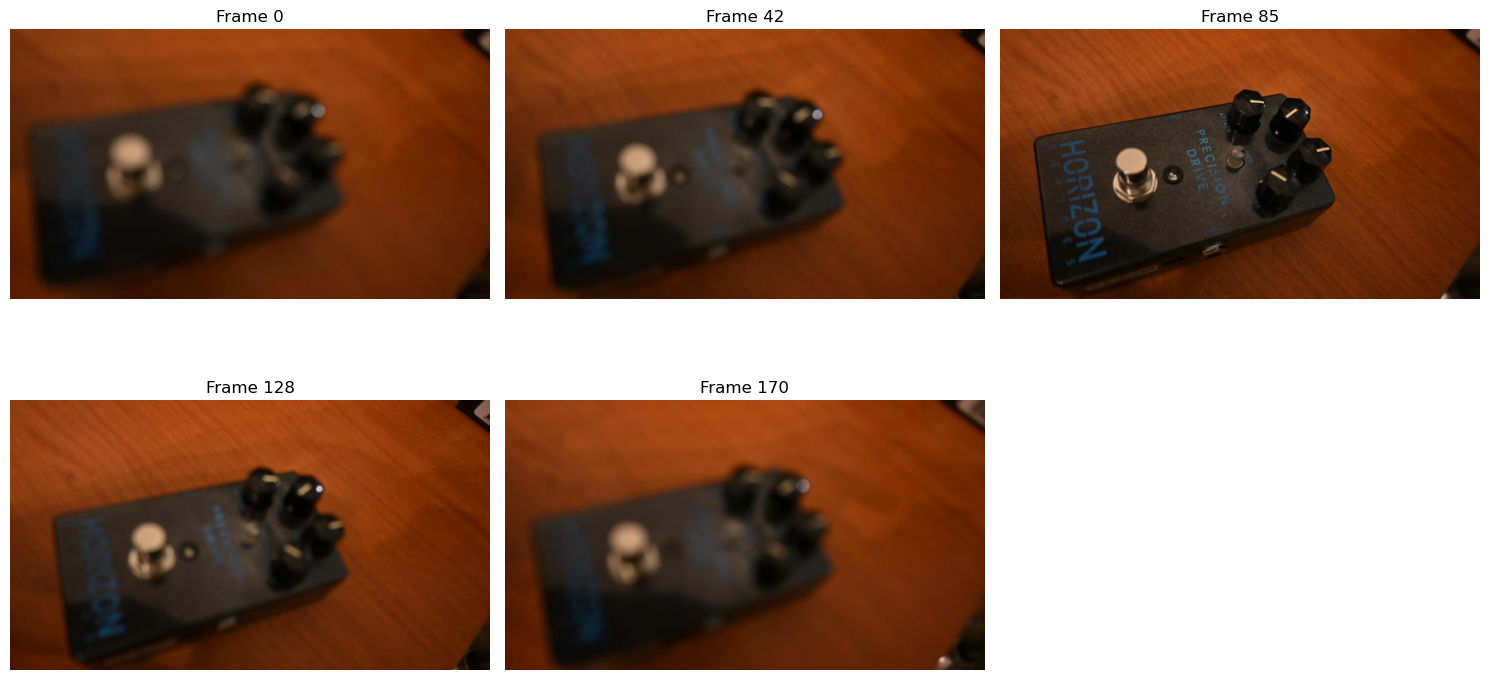

In [7]:
selected_frames = [
    0,
    frame_count // 4,
    frame_count // 2,
    3 * frame_count // 4,
    frame_count - 1,
]

plt.figure(figsize=(15, 8))

for index, frame_number in enumerate(selected_frames):
    frame = read_frame(VIDEO_PATH, frame_number)

    plt.subplot(2, 3, index + 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {frame_number}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 6. ROI central


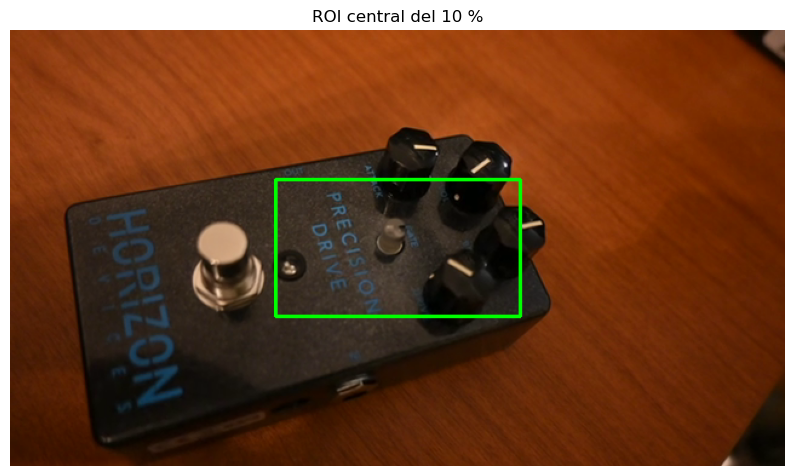

In [8]:
example_frame = read_frame(VIDEO_PATH, frame_count // 2)
roi, (x1, y1, x2, y2) = get_center_roi(example_frame, area_fraction=0.10)

frame_with_roi = example_frame.copy()
cv2.rectangle(frame_with_roi, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame_with_roi, cv2.COLOR_BGR2RGB))
plt.title("ROI central del 10 %")
plt.axis("off")
plt.show()


## 7. Procesamiento del video


In [9]:
capture = cv2.VideoCapture(str(VIDEO_PATH))

if not capture.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {VIDEO_PATH}")

full_frame_scores = []
roi_scores = []

while True:
    success, frame = capture.read()

    if not success:
        break

    full_frame_scores.append(focus_measure(frame))

    roi, _ = get_center_roi(frame, area_fraction=0.10)
    roi_scores.append(focus_measure(roi))

capture.release()

full_frame_scores = np.array(full_frame_scores)
roi_scores = np.array(roi_scores)

print(f"Frames procesados: {len(full_frame_scores)}")


Frames procesados: 171


## 8. Detección automática del máximo


In [10]:
best_full_frame = int(np.argmax(full_frame_scores))
best_roi_frame = int(np.argmax(roi_scores))

print(f"Máximo sobre frame completo: frame {best_full_frame}")
print(f"Máximo sobre ROI central: frame {best_roi_frame}")


Máximo sobre frame completo: frame 109
Máximo sobre ROI central: frame 111


## 9. Región de máximo enfoque

Se consideran parte de la región de máximo enfoque los frames cuya métrica sea
igual o superior al 95 % del valor máximo.


In [11]:
full_limit = 0.95 * full_frame_scores.max()
roi_limit = 0.95 * roi_scores.max()

full_focus_region = np.where(full_frame_scores >= full_limit)[0]
roi_focus_region = np.where(roi_scores >= roi_limit)[0]

print(
    f"Región de máximo enfoque en frame completo: "
    f"{full_focus_region[0]} a {full_focus_region[-1]}"
)

print(
    f"Región de máximo enfoque en ROI: "
    f"{roi_focus_region[0]} a {roi_focus_region[-1]}"
)


Región de máximo enfoque en frame completo: 87 a 113
Región de máximo enfoque en ROI: 107 a 113


## 10. Curvas de enfoque


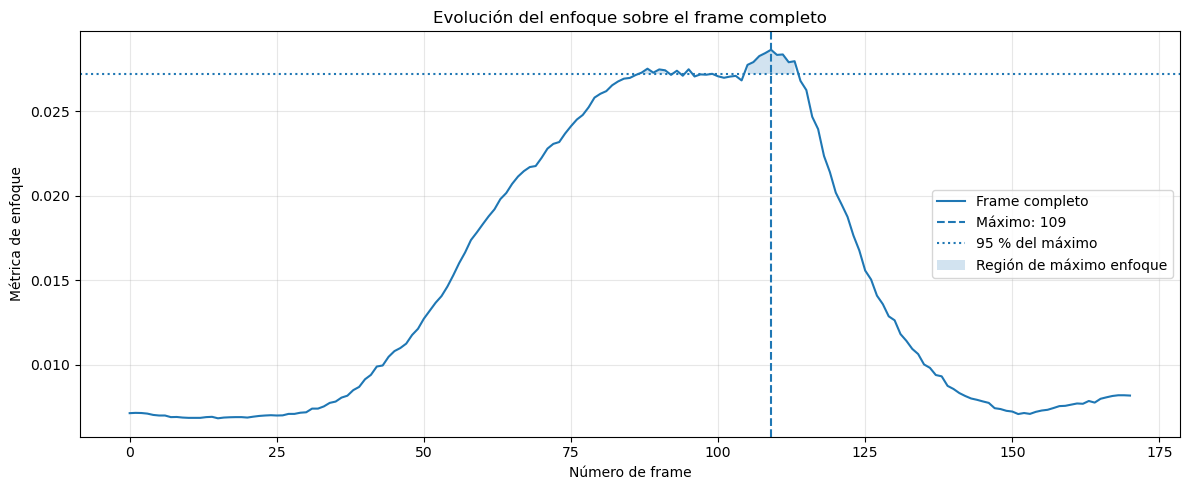

In [12]:
frames = np.arange(len(full_frame_scores))

plt.figure(figsize=(12, 5))
plt.plot(frames, full_frame_scores, label="Frame completo")
plt.axvline(best_full_frame, linestyle="--", label=f"Máximo: {best_full_frame}")
plt.axhline(full_limit, linestyle=":", label="95 % del máximo")
plt.fill_between(
    frames,
    full_frame_scores,
    full_limit,
    where=full_frame_scores >= full_limit,
    alpha=0.2,
    label="Región de máximo enfoque"
)
plt.xlabel("Número de frame")
plt.ylabel("Métrica de enfoque")
plt.title("Evolución del enfoque sobre el frame completo")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


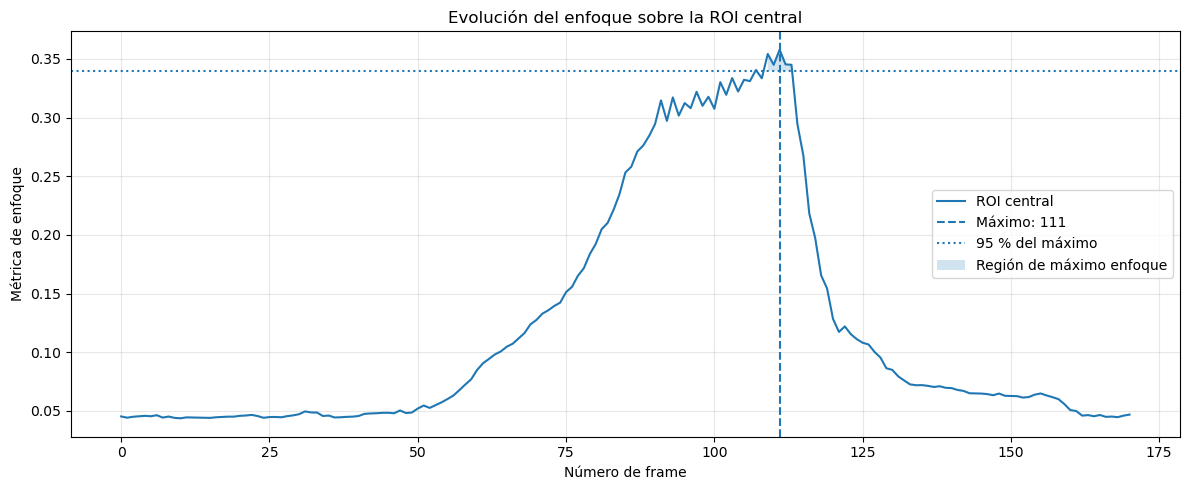

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(frames, roi_scores, label="ROI central")
plt.axvline(best_roi_frame, linestyle="--", label=f"Máximo: {best_roi_frame}")
plt.axhline(roi_limit, linestyle=":", label="95 % del máximo")
plt.fill_between(
    frames,
    roi_scores,
    roi_limit,
    where=roi_scores >= roi_limit,
    alpha=0.2,
    label="Región de máximo enfoque"
)
plt.xlabel("Número de frame")
plt.ylabel("Métrica de enfoque")
plt.title("Evolución del enfoque sobre la ROI central")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Frames detectados


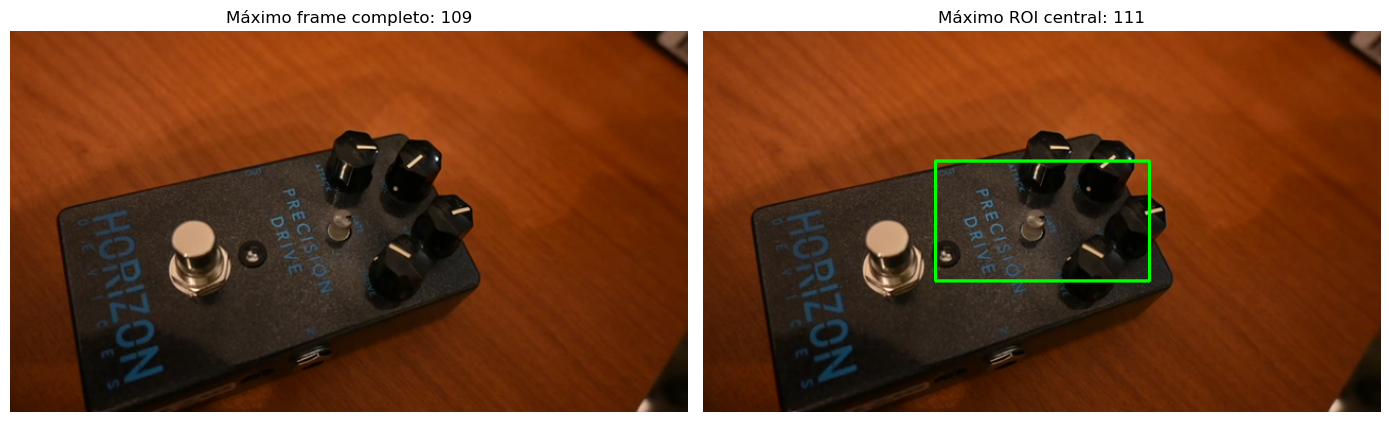

In [14]:
best_full_image = read_frame(VIDEO_PATH, best_full_frame)
best_roi_image = read_frame(VIDEO_PATH, best_roi_frame)

_, (x1, y1, x2, y2) = get_center_roi(best_roi_image, area_fraction=0.10)

best_roi_marked = best_roi_image.copy()
cv2.rectangle(best_roi_marked, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(best_full_image, cv2.COLOR_BGR2RGB))
plt.title(f"Máximo frame completo: {best_full_frame}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(best_roi_marked, cv2.COLOR_BGR2RGB))
plt.title(f"Máximo ROI central: {best_roi_frame}")
plt.axis("off")

plt.tight_layout()
plt.show()


## 12. Matriz de enfoque

Se divide una región central del frame en una grilla. Cada celda recibe su
propia métrica de enfoque.


In [15]:
def focus_grid(
    frame: np.ndarray,
    rows: int = 7,
    cols: int = 7,
    area_fraction: float = 0.30
):
    central_region, coordinates = get_center_roi(
        frame,
        area_fraction=area_fraction
    )

    x1, y1, x2, y2 = coordinates
    region_height, region_width = central_region.shape[:2]

    cell_height = region_height // rows
    cell_width = region_width // cols

    matrix = np.zeros((rows, cols), dtype=float)

    for row in range(rows):
        for col in range(cols):
            cy1 = row * cell_height
            cy2 = (row + 1) * cell_height
            cx1 = col * cell_width
            cx2 = (col + 1) * cell_width

            cell = central_region[cy1:cy2, cx1:cx2]
            matrix[row, col] = focus_measure(cell)

    return matrix, coordinates


In [16]:
def draw_focus_grid(
    frame: np.ndarray,
    matrix: np.ndarray,
    coordinates: tuple[int, int, int, int]
) -> np.ndarray:
    result = frame.copy()

    x1, y1, x2, y2 = coordinates
    rows, cols = matrix.shape

    cell_width = (x2 - x1) // cols
    cell_height = (y2 - y1) // rows

    cell_limit = 0.95 * matrix.max()

    for row in range(rows):
        for col in range(cols):
            px1 = x1 + col * cell_width
            py1 = y1 + row * cell_height
            px2 = px1 + cell_width
            py2 = py1 + cell_height

            if matrix[row, col] >= cell_limit:
                thickness = 3
            else:
                thickness = 1

            cv2.rectangle(
                result,
                (px1, py1),
                (px2, py2),
                (0, 255, 0),
                thickness
            )

    return result


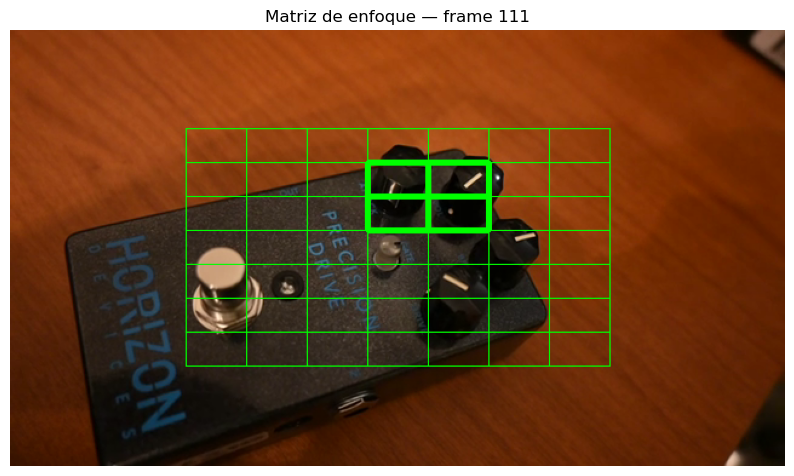

Matriz de enfoque:
[[0.111 0.091 0.073 0.571 0.379 0.425 0.073]
 [0.274 0.424 0.519 0.921 0.904 0.566 0.087]
 [0.704 0.697 0.717 0.939 0.907 0.551 0.145]
 [0.526 0.686 0.749 0.755 0.735 0.774 0.117]
 [0.539 0.804 0.726 0.824 0.827 0.646 0.109]
 [0.709 0.741 0.692 0.694 0.795 0.729 0.125]
 [0.719 0.473 0.567 0.655 0.705 0.421 0.109]]


In [17]:
focus_matrix, grid_coordinates = focus_grid(
    best_roi_image,
    rows=7,
    cols=7,
    area_fraction=0.30
)

frame_with_grid = draw_focus_grid(
    best_roi_image,
    focus_matrix,
    grid_coordinates
)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame_with_grid, cv2.COLOR_BGR2RGB))
plt.title(f"Matriz de enfoque — frame {best_roi_frame}")
plt.axis("off")
plt.show()

print("Matriz de enfoque:")
print(np.round(focus_matrix, 3))


## 13. Punto extra: unsharp masking


In [18]:
def unsharp_mask(
    image: np.ndarray,
    sigma: float = 1.5,
    amount: float = 1.0
) -> np.ndarray:
    image_float = image.astype(np.float32)

    blurred = cv2.GaussianBlur(
        image_float,
        ksize=(0, 0),
        sigmaX=sigma
    )

    sharpened = image_float + amount * (image_float - blurred)

    return np.clip(sharpened, 0, 255).astype(np.uint8)


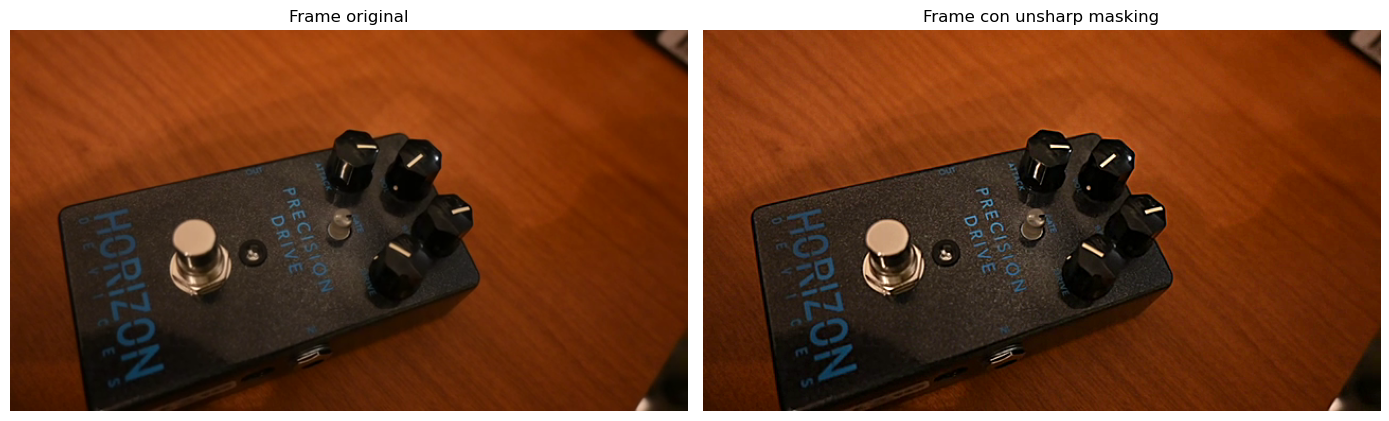

In [19]:
sharpened_image = unsharp_mask(
    best_roi_image,
    sigma=1.5,
    amount=1.0
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(best_roi_image, cv2.COLOR_BGR2RGB))
plt.title("Frame original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB))
plt.title("Frame con unsharp masking")
plt.axis("off")

plt.tight_layout()
plt.show()


## 14. Conclusión

La métrica de enfoque se calculó para todos los frames del video sobre la imagen
completa y sobre una ROI central. Luego se detectaron automáticamente el frame
de mayor enfoque y una región cercana al máximo.

La matriz de enfoque permite observar cómo se distribuye el enfoque dentro de
una región del frame. Finalmente, se aplicó unsharp masking como mejora visual
opcional.
